<a href="https://colab.research.google.com/github/HYPEREON008/CV-stuff/blob/main/day3-assignment/dogs_cats_classification_playground.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Getting microsoft's cats and dogs database from kaggle

In [23]:
# ! pip install kaggle

In [24]:
# %%writefile kaggle.json
# {
#   "username": "sanmitragoswami",
#   "key": "KGAT_84a2e1778522ab79845183e6fd564740"
# }

# !mkdir -p ~/.kaggle
# !mv kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

In [25]:
# !kaggle datasets list ## test if kaggle loaded
# !kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset
# !unzip microsoft-catsvsdogs-dataset.zip
# !ls

## Python Imports

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

## Data Preparation

In [27]:
# Data Augmentation for Training
# Compose means apply these transforms in order one after the other
train_transforms = transforms.Compose([
    transforms.Resize(256), # shorter side to 256 pixels
    transforms.CenterCrop(224), # randomly crops 224*224 patch from this
    transforms.RandomHorizontalFlip(), # randomly flips img laterally with 0.5 prob
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),

    transforms.ToTensor(), # converts img to pytorch tensor output shape becomes (c,h,w)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
 # image net normalisation
])

In [28]:
# No Augmentation for Validation/Test
val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

### Manual Split of Full Data

In [29]:
# import os

# base = "data"
# for split in ["train", "val", "test"]:
#     for cls in ["Cat", "Dog"]:
#         os.makedirs(f"{base}/{split}/{cls}", exist_ok=True)
# import random
# import shutil

# def split_class(class_name):
#     src = f"PetImages/{class_name}"
#     files = os.listdir(src)
#     random.shuffle(files)

#     n = len(files)
#     train_end = int(0.8 * n)
#     val_end = int(0.9 * n)

#     splits = {
#         "train": files[:train_end],
#         "val": files[train_end:val_end],
#         "test": files[val_end:]
#     }

#     for split, split_files in splits.items():
#         for f in split_files:
#             shutil.copy(
#                 os.path.join(src, f),
#                 f"data/{split}/{class_name}/{f}"
#             )

# split_class("Cat")
# split_class("Dog")


In [30]:
import os
os.chdir("/content/drive/My Drive/iBot DC tenure/datasets")
# Load Datasets
train_data = datasets.ImageFolder('data/train', transform=train_transforms)
test_data = datasets.ImageFolder('data/test', transform=val_transforms)
val_data = datasets.ImageFolder('data/val', transform=val_transforms)


In [31]:
# Create Data Loaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print(f"Train data size: {len(train_data)}")
print(f"Validation data size: {len(val_data)}")
print(f"Test data size: {len(test_data)}")

Train data size: 19999
Validation data size: 2499
Test data size: 2502


## Model Setup

In [32]:
# Load pretrained ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
# Freeze all layers
for param in model.parameters():
    param.requires_grad = False
# Replace the last fully connected layer with a new one for binary classification
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)
# Move to GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"Using device: {device}")
print(f"Training only Final Layer with {model.fc.in_features} output to 2")

Using device: cpu
Training only Final Layer with 512 output to 2


## Training Setup

In [33]:
# Loss and Optimiser
criterion = nn.CrossEntropyLoss()
## cross entropy loss is a loss function used for multi-class classification
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
## creates an adam optimizer, that updates only model's fully connected params

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

# Training Tracking
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_accuracy = 0.0


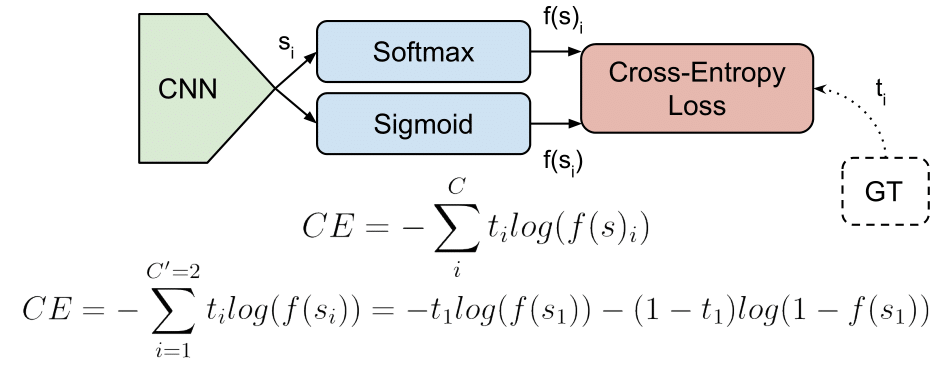

### CNN
- Takes an input image
- Extracts features through convolution + pooling
- Outputs a vector of scores (also called logits)
### $S_i$ - Logits
- It's the raw output of the CNN for class i
- Can be any real number: +ve, -ve, large, small
- Needs an activation function to convert to probabilities
### Sigmoid
used for binary or multi-class classification
$f(s_i)$
### Softmax
used for multi-class classification
$f(s)_i$ = probability that input belongs to class i
### GT
ground truth



### Scheduler
- optimizer: the optimizer whose LR will be changed
- mode: (=min) so lower is better
- patience: wait n epochs if monitored value does noy improve reduce LR
- factor: newLR = factor$\times$oldLR

## Training Loop

## Evaluation on Test Set

In [34]:
n_epochs = 10
for epoch in range(n_epochs):
    # Training Phase
    model.train()
    running_losses = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        # Fwd
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        # Bck
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        #Statistics
        running_losses += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_losses/len(train_loader)
    train_accuracy = 100*correct/total
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # Validation Phase
    model.eval()
    val_running_losses = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_losses += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_losses/len(val_loader)
    val_accuracy = 100*val_correct/val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    ## update learning rate
    scheduler.step(val_loss)
    ## save best model
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"Saved best model with val_accuracy: {best_val_accuracy:.2f}%")

    print(f"Epoch: [{epoch+1}/{n_epochs}]")
    print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")
    print()


KeyboardInterrupt: 

In [ ]:
# Load best model
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max()

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100*correct/total
print(f"Test Accuracy: {test_accuracy:.2f}%")

.cpu(): This method moves the tensor from its current device (e.g., a GPU, represented as 'cuda') to the host system's CPU memory. This is a necessary step because NumPy is a CPU-based library and cannot directly work with data stored in GPU memory. If the tensor is already on the CPU, this method does nothing.

.numpy(): This method converts the CPU-resident PyTorch tensor into a NumPy ndarray. The resulting NumPy array and the original PyTorch tensor will share the same underlying memory, meaning that in-place modifications to the NumPy array will affect the original tensor

## Visualisation

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [ ]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize(14, 5))

ax1.plot(train_losses, label="Train Loss")
ax1.plot(val_losses, label="Val Loss")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.set_title("Training and Validation Loss")
ax1.legend()

ax2.plot(train_accuracies, label="Train Accuracy")
ax2.plot(val_accuracies, label="Val Accuracy")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy %")
ax2.set_title("Training and Validation Accuracy")
ax2.legend()

plt.tight_layout()
# plt.save_fig("training_curves.png")
plt.show()

In [ ]:
# Confusion Matrix
cmatrix = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cmatrix, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
# plt.save_fig("confusion_matrix.png")
plt.show()

sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
- annot: if True, the data value is written in each cell. Can also be a separate array for custom annotations.
- fmt: String formatting code to use when annot is True (e.g., ".2f" for two decimal places, "d" for integers).
